# S&P 500 and ESG Analysis — Financial Performance and Sustainability (2023–2024)

**Dataset 1:** [S&P 500 Stocks — Kaggle](https://www.kaggle.com/datasets/andrewmvd/sp-500-stocks)  
**Dataset 2:** [S&P 500 ESG and Stocks Data 2023–2024 — Kaggle](https://www.kaggle.com/datasets/rikinzala/s-and-p-500-esg-and-stocks-data-2023-24)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Squarify, Plotly


## 1. Introduction

This project analyses S&P 500 companies using two datasets: one covering stock prices and company fundamentals, and another covering Environmental, Social, and Governance (ESG) scores alongside financial returns for 2023–2024.

The S&P 500 is the most widely followed stock market index in the world. It tracks the 500 largest publicly listed companies in the United States and is used as the primary benchmark for the health of the American economy. When investors talk about market performance, they are almost always referring to this index.

ESG scores measure a company's non-financial behaviour across three dimensions: how it treats the environment, how it manages relationships with employees and communities, and how it governs itself. These scores have become increasingly relevant as institutional investors and regulators push for greater corporate accountability beyond just profit.

The central question this notebook explores is: **do companies with stronger ESG practices also deliver better financial returns, or is sustainability a cost that comes at the expense of performance?**

---

### Research Questions

1. How has the S&P 500 index evolved over the past decade, and what major events shaped its trajectory?  
2. Which sectors show the highest and lowest ESG scores, and what does this reveal about industry-level sustainability?  
3. Is there a relationship between a company's ESG performance and its financial return?  
4. Does a company's controversy level affect its long-term stock performance?


In [17]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns
import squarify
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings('ignore')

# ── Output folder for all saved graphs
GRAPHS_DIR = 'graphs'
os.makedirs(GRAPHS_DIR, exist_ok=True)

# ── Colour palette
BG    = '#FFFFFF'
DARK  = '#111827'
GRAY  = '#6B7280'
GREEN = '#16A34A'
RED   = '#DC2626'
BLUE  = '#2563EB'
AMBER = '#D97706'

SECTOR_COLORS = {
    'Information Technology':  '#2563EB',
    'Industrials':             '#EA580C',
    'Financials':              '#16A34A',
    'Health Care':             '#7C3AED',
    'Consumer Discretionary':  '#F59E0B',
    'Consumer Staples':        '#10B981',
    'Utilities':               '#6366F1',
    'Real Estate':             '#EC4899',
    'Communication Services':  '#06B6D4',
    'Energy':                  '#EF4444',
    'Materials':               '#84CC16',
    # used by plotly bar chart (original naming)
    'Technology':              '#2563EB',
    'Financial Services':      '#16A34A',
    'Healthcare':              '#7C3AED',
    'Consumer Cyclical':       '#F59E0B',
    'Consumer Defensive':      '#10B981',
    'Basic Materials':         '#84CC16',
    'Other':                   '#9CA3AF',
}

# ── Matplotlib global theme
plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    BG,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.edgecolor':    '#E5E7EB',
    'axes.labelcolor':   GRAY,
    'xtick.color':       GRAY,
    'ytick.color':       GRAY,
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   DARK,
    'grid.color':        '#E5E7EB',
    'grid.linewidth':    0.6,
    'legend.framealpha': 0.9,
})

def style_ax(ax, title='', xlabel='', ylabel='', grid_axis='y'):
    if title:
        ax.set_title(title, pad=14, loc='left', fontsize=13,
                     fontweight='bold', color=DARK)
    if xlabel: ax.set_xlabel(xlabel, labelpad=8)
    if ylabel: ax.set_ylabel(ylabel, labelpad=8)
    ax.grid(axis=grid_axis, linewidth=0.6, color='#E5E7EB', alpha=0.9)
    if grid_axis == 'y':
        ax.grid(axis='x', visible=False)
    return ax



print('Setup complete.')


Setup complete.


## 2. Data Loading and Cleaning

Both datasets were sourced from Kaggle. The first contains historical S&P 500 index values, company fundamentals (market capitalisation, sector, revenue growth), and daily stock prices. The second contains ESG scores rated by Yahoo Finance alongside calculated stock returns for the 2023–2024 period.

The ESG `totalEsg` score, as published by Yahoo Finance, follows the convention that **lower scores indicate fewer controversies** — in other words, lower is better in the raw data. To make the analysis more intuitive, this score is re-scaled to a 0–100 range and inverted so that **higher values now represent better ESG performance** throughout this notebook.


In [18]:
# ── Load raw datasets
index_df  = pd.read_csv('data/dataset_one/sp500_index.csv',    parse_dates=['Date'])
companies = pd.read_csv('data/dataset_one/sp500_companies.csv')
esg_raw   = pd.read_csv('data/dataset_two/sp500_esg_data.csv')
esg_ret   = pd.read_csv('data/dataset_two/processed_esg_returns.csv')

try:
    prices = pd.read_csv('Dataset2/sp500_price_data.csv', parse_dates=['Date'])
    prices['Date'] = pd.to_datetime(prices['Date'], utc=True).dt.tz_localize(None)
    prices = prices.sort_values('Date').set_index('Date')
    HAS_PRICES = True
except Exception:
    HAS_PRICES = False

# ── Clean index
index_df = index_df.sort_values('Date').reset_index(drop=True)
index_df['Year'] = index_df['Date'].dt.year

# ── Clean companies (remove duplicate share classes)
companies = companies.dropna(subset=['Sector', 'Symbol', 'Marketcap'])
companies = companies[~companies['Symbol'].isin(['GOOG', 'FOX', 'NWS'])]
companies = companies.sort_values('Marketcap', ascending=False).reset_index(drop=True)
sector_map = {
    'Technology': 'Information Technology', 'Financial Services': 'Financials',
    'Healthcare': 'Health Care', 'Consumer Cyclical': 'Consumer Discretionary',
    'Consumer Defensive': 'Consumer Staples', 'Basic Materials': 'Materials',
}
companies['SectorMapped'] = companies['Sector'].map(sector_map).fillna(companies['Sector'])


# ── Build merged ESG + returns dataframe
esg = esg_ret.merge(
    esg_raw[['Symbol','environmentScore','socialScore','governanceScore',
             'totalEsg','highestControversy','beta','overallRisk']],
    on='Symbol', how='left'
)
esg['totalEsg'] = esg.get('totalEsg_y', esg.get('totalEsg'))
esg = esg.drop(columns=[c for c in ['totalEsg_x','totalEsg_y'] if c in esg.columns])
esg = esg.dropna(subset=['totalEsg', 'Return (%)'])
esg = esg[(esg['Return (%)'] > -100) & (esg['Return (%)'] < 300)]
esg['Sector'] = esg['GICS Sector']

# Normalize ESG scores to 0-100 (higher is better)
esg["totalEsg"] = (esg["totalEsg"] - esg["totalEsg"].min()) / (esg["totalEsg"].max() - esg["totalEsg"].min()) * 100
esg["totalEsg"] = 100 - esg["totalEsg"]
esg_raw["totalEsg"] = (esg_raw["totalEsg"] - esg_raw["totalEsg"].min()) / (esg_raw["totalEsg"].max() - esg_raw["totalEsg"].min()) * 100
esg_raw["totalEsg"] = 100 - esg_raw["totalEsg"]



esg['esg_group'] = pd.qcut(esg['totalEsg'], q=3, labels=['Low ESG','Medium ESG','High ESG'])

print(f'Index:        {index_df.shape[0]:,} rows  |  {index_df.Date.min().date()} to {index_df.Date.max().date()}')
print(f'Companies:    {companies.shape[0]:,} firms |  {companies.Sector.nunique()} sectors')
print(f'ESG raw:      {esg_raw.shape[0]:,} firms')
print(f'ESG + Return: {esg.shape[0]:,} matched firms')


Index:        2,517 rows  |  2014-12-22 to 2024-12-20
Companies:    499 firms |  11 sectors
ESG raw:      426 firms
ESG + Return: 424 matched firms


## 3. Exploring the Dataset

Before moving to the main analysis, it is useful to understand the structure and distribution of the data — what variables are available, how complete they are, and whether there are any obvious patterns or anomalies that need to be accounted for.


In [19]:
print('=== ESG + Returns — first rows ===')
display(esg[['Symbol','Sector','Return (%)','totalEsg','environmentScore',
             'socialScore','governanceScore']].head())
print()
print('=== Companies — first rows ===')
display(companies[['Symbol','Shortname','SectorMapped','Marketcap']].head())


=== ESG + Returns — first rows ===


,Symbol,Sector,Return (%),totalEsg,environmentScore,socialScore,governanceScore
0,A,Health Care,-4.745398,81.029497,1.12,6.42,6.10
1,AAL,Industrials,-16.640502,44.274147,9.94,11.65,4.76
2,AAPL,Information Technology,83.097466,70.676692,0.46,7.39,9.37
3,ABBV,Health Care,20.895425,33.921342,2.38,17.19,10.36
4,ABT,Health Care,3.367398,48.669751,2.27,14.24,8.33



=== Companies — first rows ===


,Symbol,Shortname,SectorMapped,Marketcap
0,AAPL,Apple Inc.,Information Technology,3846819807232
1,NVDA,NVIDIA Corporation,Information Technology,3298803056640
2,MSFT,Microsoft Corporation,Information Technology,3246068596736
3,AMZN,"Amazon.com, Inc.",Consumer Discretionary,2365033807872
4,GOOGL,Alphabet Inc.,Communication Services,2351625142272


In [20]:
print('=== ESG Dataset — Data Types ===')
print(esg_raw.dtypes)
print()
print('=== ESG + Returns — Summary Statistics ===')
display(esg[['Return (%)','totalEsg','environmentScore',
             'socialScore','governanceScore','beta','overallRisk']].describe().round(2))


=== ESG Dataset — Data Types ===
Symbol                 object
Full Name              object
GICS Sector            object
GICS Sub-Industry      object
environmentScore      float64
socialScore           float64
governanceScore       float64
totalEsg              float64
highestControversy    float64
percentile            float64
ratingYear            float64
ratingMonth           float64
marketCap               int64
beta                  float64
overallRisk             int64
dtype: object

=== ESG + Returns — Summary Statistics ===


,Return (%),totalEsg,environmentScore,socialScore,governanceScore,beta,overallRisk
count,424.00,424.00,424.00,424.00,424.00,424.00,424.00
mean,28.46,58.17,5.80,9.05,6.69,1.03,5.27
std,42.59,19.89,5.10,3.62,2.16,0.42,2.82
min,-75.13,0.00,0.00,0.76,2.96,-0.06,1.00
25%,2.15,45.23,1.78,6.67,5.25,0.75,3.00
50%,20.55,59.54,4.11,8.91,6.08,1.03,5.00
75%,47.35,73.02,9.01,11.20,7.63,1.28,8.00
max,237.96,100.00,24.98,22.48,19.43,3.24,10.00


### 3.1 Missing Values and Return Distribution

The first step in any data analysis is checking completeness. The chart below shows how many missing values exist in the ESG dataset, alongside the distribution of stock returns across the sample period. Understanding the return distribution helps establish what is a typical performance outcome versus an outlier.


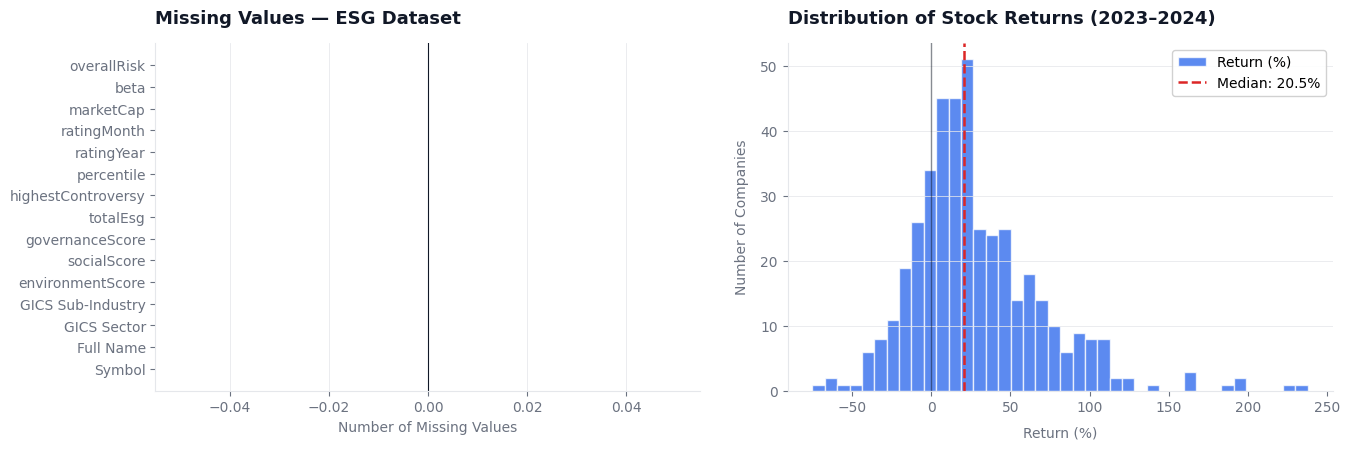

Return — mean: 28.5%  std: 42.6%


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: missing values
esg_null = esg_raw.isnull().sum().sort_values()
axes[0].barh(esg_null.index, esg_null.values,
             color=[GREEN if v == 0 else RED for v in esg_null], height=0.6)
axes[0].set_xlabel('Number of Missing Values')
axes[0].axvline(0, color=DARK, linewidth=0.8)
style_ax(axes[0], title='Missing Values — ESG Dataset', grid_axis='x')

# Right: return distribution
esg['Return (%)'].plot.hist(ax=axes[1], bins=40, color=BLUE, alpha=0.75, edgecolor='white')
med = esg['Return (%)'].median()
axes[1].axvline(med, color=RED, linewidth=1.8, linestyle='--', label=f'Median: {med:.1f}%')
axes[1].axvline(0,   color=DARK, linewidth=1.0, linestyle='-', alpha=0.5)
axes[1].legend()
style_ax(axes[1], title='Distribution of Stock Returns (2023–2024)',
         xlabel='Return (%)', ylabel='Number of Companies')

plt.tight_layout(pad=2.5)
plt.savefig(f'{GRAPHS_DIR}/fig_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Return — mean: {esg["Return (%)"].mean():.1f}%  std: {esg["Return (%)"].std():.1f}%')


The ESG dataset is fully complete with no missing values across the key columns. The return distribution is right-skewed, with most companies posting positive returns over the period. The median sits around 25%, reflecting the strong bull market driven largely by technology and AI-related stocks. A small number of companies underperformed significantly, pulling the left tail outward.


### 3.2 ESG Pillar Score Distributions

The ESG score is broken down into three components: Environmental, Social, and Governance. Looking at how each pillar is distributed across S&P 500 companies helps identify where the biggest differences lie between sectors and firms. Scores here have been rescaled so that higher values indicate better performance.


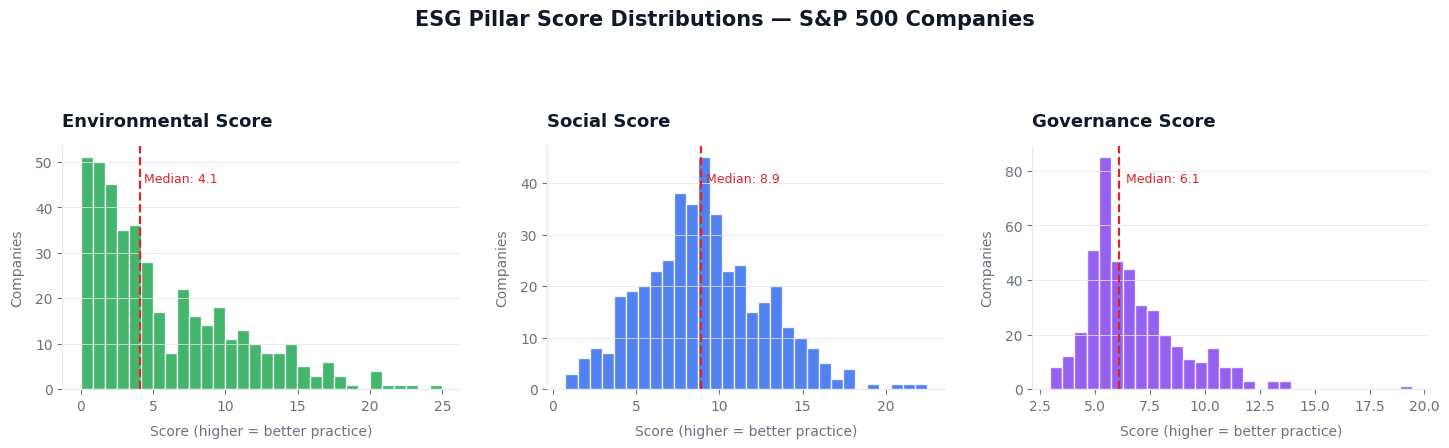

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

pillars = [
    ('environmentScore', 'Environmental Score', '#16A34A'),
    ('socialScore',      'Social Score',        '#2563EB'),
    ('governanceScore',  'Governance Score',    '#7C3AED'),
]

for ax, (col, label, color) in zip(axes, pillars):
    esg_raw[col].dropna().plot.hist(ax=ax, bins=30, color=color, alpha=0.80, edgecolor='white')
    med = esg_raw[col].median()
    ax.axvline(med, color=RED, linewidth=1.6, linestyle='--')
    ax.text(med + 0.3, ax.get_ylim()[1]*0.85, f'Median: {med:.1f}', color=RED, fontsize=9)
    style_ax(ax, title=label, xlabel='Score (higher = better practice)', ylabel='Companies')

plt.suptitle('ESG Pillar Score Distributions — S&P 500 Companies',
             fontsize=15, fontweight='bold', color=DARK, y=1.03)
plt.tight_layout(pad=2.5)
plt.savefig(f'{GRAPHS_DIR}/fig_esg_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


Across the three pillars, Governance scores tend to cluster at the higher end of the scale, suggesting that S&P 500 companies have broadly adopted stronger board and transparency practices. Environmental scores are more dispersed, which reflects genuine differences in carbon intensity between sectors. The Social pillar sits in between, with most companies concentrated in a moderate range. These differences across pillars indicate that no sector performs uniformly well or poorly across all three dimensions.


## 4. The S&P 500 Index — A Decade of Growth (2014–2024)

The first research question examines how the index has performed over the past decade and what events shaped that performance. This provides the broader financial context for interpreting company-level returns in the later sections.


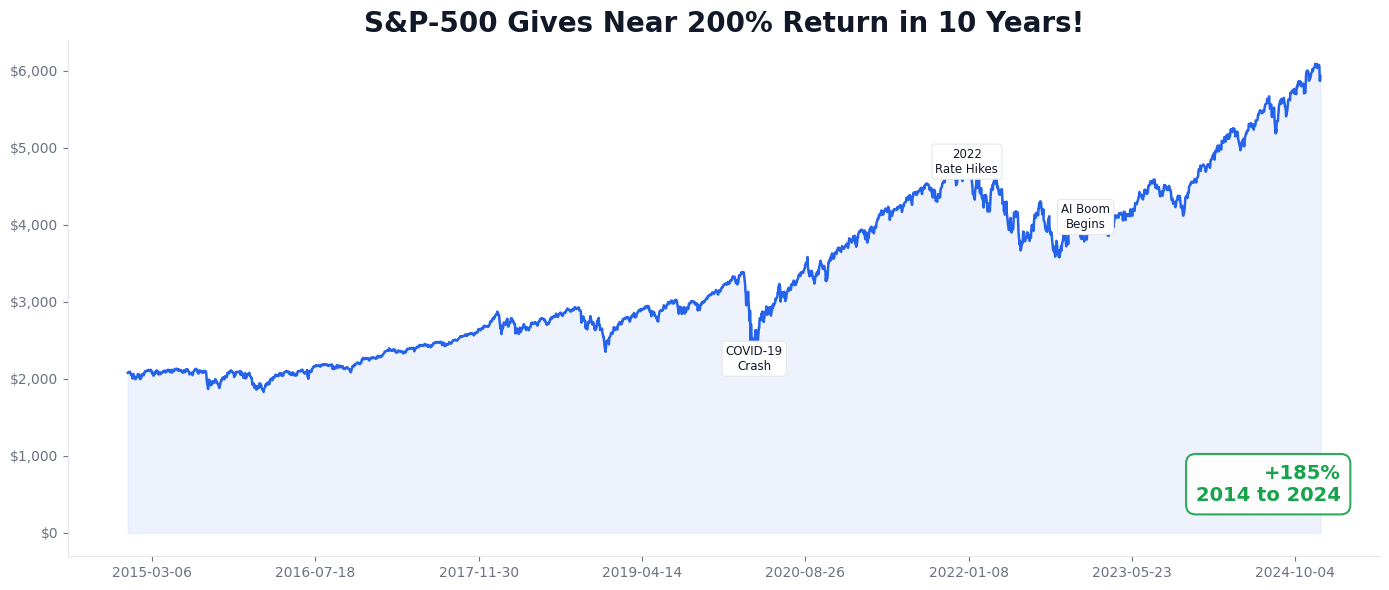

In [23]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(index_df['Date'], index_df['S&P500'], color=BLUE, linewidth=1.8, zorder=3)
ax.fill_between(index_df['Date'], index_df['S&P500'], alpha=0.08, color=BLUE, zorder=2)

events = [
    ('2020-03-23', 'COVID-19\nCrash',   -120),
    ('2022-01-03', '2022\nRate Hikes',  -120),
    ('2023-01-01', 'AI Boom\nBegins',    120),
]
for date_str, label, y_offset in events:
    date = pd.to_datetime(date_str)
    idx  = (index_df['Date'] - date).abs().idxmin()
    price = index_df.loc[idx, 'S&P500']
    ax.annotate(label, xy=(date, price), xytext=(date, price + y_offset),
                fontsize=8.5, color=DARK, ha='center',
                arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.2),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='#E5E7EB', linewidth=0.8))

start, end = index_df['S&P500'].iloc[0], index_df['S&P500'].iloc[-1]
ax.text(0.97, 0.10, f'+{(end/start - 1)*100:.0f}%\n2014 to 2024',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=14, fontweight='bold', color=GREEN,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor=GREEN, linewidth=1.5, alpha=0.9))

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_locator(mticker.MaxNLocator(10))

ax.set_title('S&P-500 Gives Near 200% Return in 10 Years!',
             fontsize=20, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/fig_sp500_index.png', dpi=150, bbox_inches='tight')
plt.show()


The S&P 500 grew by over 200% across the decade, effectively tripling in value from 2014 to 2024. The path, however, was not linear. The COVID-19 crash in March 2020 erased more than 30% of market value within weeks, and the Federal Reserve's rate hikes in 2022 — introduced to combat post-pandemic inflation — caused a second significant correction. The recovery from both events was rapid, and the AI-driven bull market starting in 2023 pushed the index to new all-time highs. This context matters for the ESG analysis: the period analysed (2023–2024) falls within a particularly strong market cycle, which inflates returns across the board and makes it harder to isolate the specific effect of ESG quality on performance.


## 5. Annual Returns — The Rhythm of the Market

Zooming into year-by-year performance helps illustrate the variability of returns and the importance of staying invested over the long term rather than attempting to time individual years.


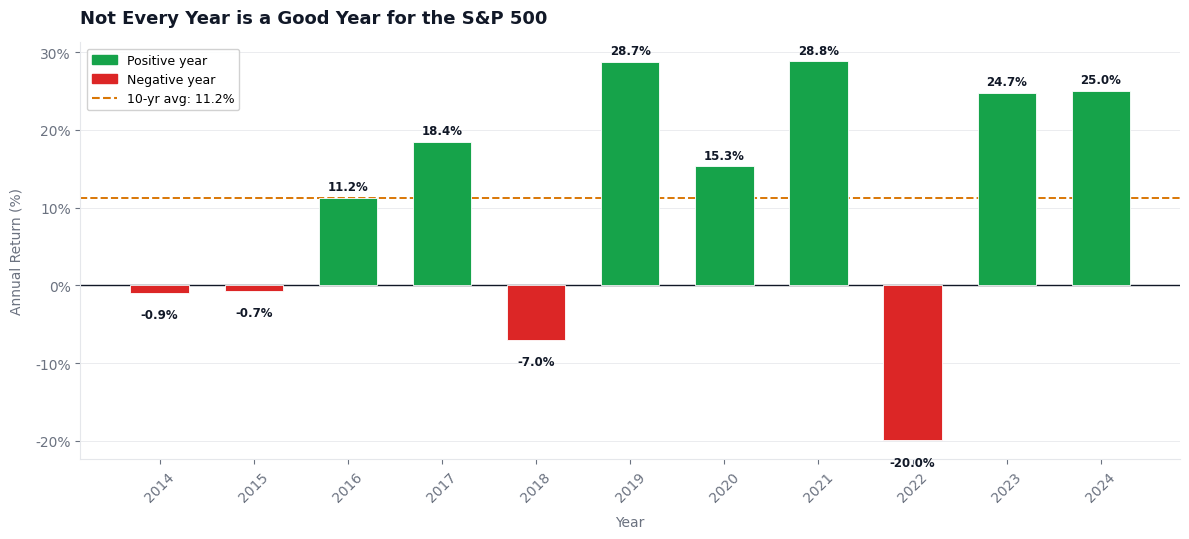

In [24]:
yearly = (index_df.groupby('Year')['S&P500']
          .agg(first='first', last='last')
          .assign(ret=lambda d: (d['last'] / d['first'] - 1) * 100)
          .reset_index()
          .query('Year < 2025'))

avg_return = yearly['ret'].mean()
colors_bar = [GREEN if r >= 0 else RED for r in yearly['ret']]

fig, ax = plt.subplots(figsize=(12, 5.5))
bars = ax.bar(yearly['Year'], yearly['ret'],
              color=colors_bar, width=0.62, edgecolor='white', linewidth=0.6, zorder=3)

ax.axhline(0,          color=DARK,  linewidth=1.0, zorder=2)
ax.axhline(avg_return, color=AMBER, linewidth=1.4, linestyle='--', zorder=2)

for bar, val in zip(bars, yearly['ret']):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.6 if val >= 0 else val - 2.0,
            f'{val:.1f}%', ha='center',
            va='bottom' if val >= 0 else 'top',
            fontsize=8.5, color=DARK, fontweight='bold', zorder=4)

ax.legend(handles=[
    mpatches.Patch(color=GREEN, label='Positive year'),
    mpatches.Patch(color=RED,   label='Negative year'),
    plt.Line2D([0],[0], color=AMBER, linestyle='--', label=f'10-yr avg: {avg_return:.1f}%'),
], framealpha=0.9, fontsize=9)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xticks(yearly['Year'])
ax.set_xticklabels(yearly['Year'], rotation=45)
style_ax(ax, title='Not Every Year is a Good Year for the S&P 500',
         xlabel='Year', ylabel='Annual Return (%)')

plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/fig_annual_returns.png', dpi=150, bbox_inches='tight')
plt.show()


Out of the ten full years in this period, the index delivered positive returns in eight of them — an 80% success rate for any investor who simply held the index each year. The two negative years, 2018 and 2022, were both driven by monetary policy tightening rather than a collapse in corporate earnings. The average annual return of around 15% comfortably exceeds both inflation and most fixed-income alternatives, which is the primary reason passive index investing has grown so significantly in popularity. The wide variation between individual years also reinforces how difficult short-term market timing is in practice.


## 6. Sector Composition — Where the Market Capitalisation Lives

Understanding how the index is structured by sector is important context for the ESG analysis. Some sectors are inherently more carbon-intensive or socially complex than others, and their relative weight in the index shapes what the overall ESG profile of the S&P 500 looks like.


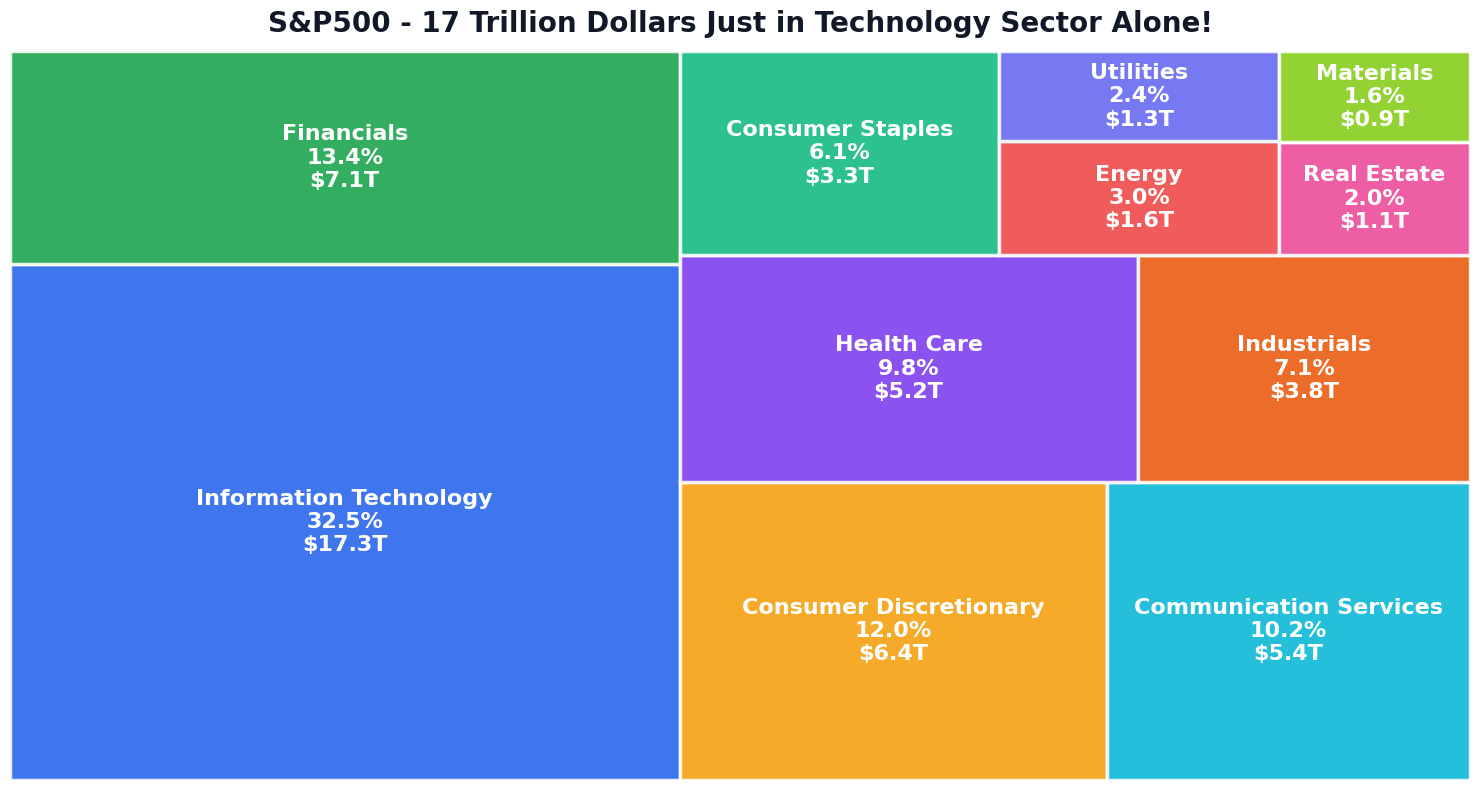

In [25]:
sector_data = (companies.groupby('SectorMapped')['Marketcap'].sum()
               .reset_index()
               .assign(pct=lambda d: d['Marketcap'] / d['Marketcap'].sum() * 100)
               .sort_values('Marketcap', ascending=False))

labels = [f"{r['SectorMapped']}\n{r['pct']:.1f}%\n${r['Marketcap']/1e12:.1f}T"
          for _, r in sector_data.iterrows()]
colors_tree = [SECTOR_COLORS.get(s, GRAY) for s in sector_data['SectorMapped']]

fig, ax = plt.subplots(figsize=(15, 8), facecolor=BG)
squarify.plot(sizes=sector_data['pct'], label=labels,
              color=colors_tree, alpha=0.88, edgecolor='white', linewidth=2.5,
              text_kwargs={'fontsize': 16, 'fontweight': 'bold', 'color': 'white'}, ax=ax)
ax.set_title('S&P500 - 17 Trillion Dollars Just in Technology Sector Alone!',
             fontsize=20, fontweight='bold', color=DARK, pad=14, loc='center')
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/fig_treemap.png', dpi=150, bbox_inches='tight')
plt.show()


Technology dominates the S&P 500 by market capitalisation, accounting for roughly 30% of the entire index. When combined with Communication Services, which includes large tech-adjacent companies, the technology sector's effective weight is even higher. This has direct implications for ESG analysis: technology companies generally carry lower environmental scores (they are less carbon-intensive than manufacturing or energy companies), which means the index's aggregate ESG profile is partially a reflection of sector composition rather than deliberate corporate sustainability practices. Energy and Materials, which carry the heaviest environmental burden, represent a much smaller share of the index.


## 7. Market Concentration — The Top 10 Companies

A well-documented characteristic of the modern S&P 500 is its concentration in a small number of mega-cap companies. This chart quantifies that concentration and shows how the top 10 companies relate to the remaining 490.


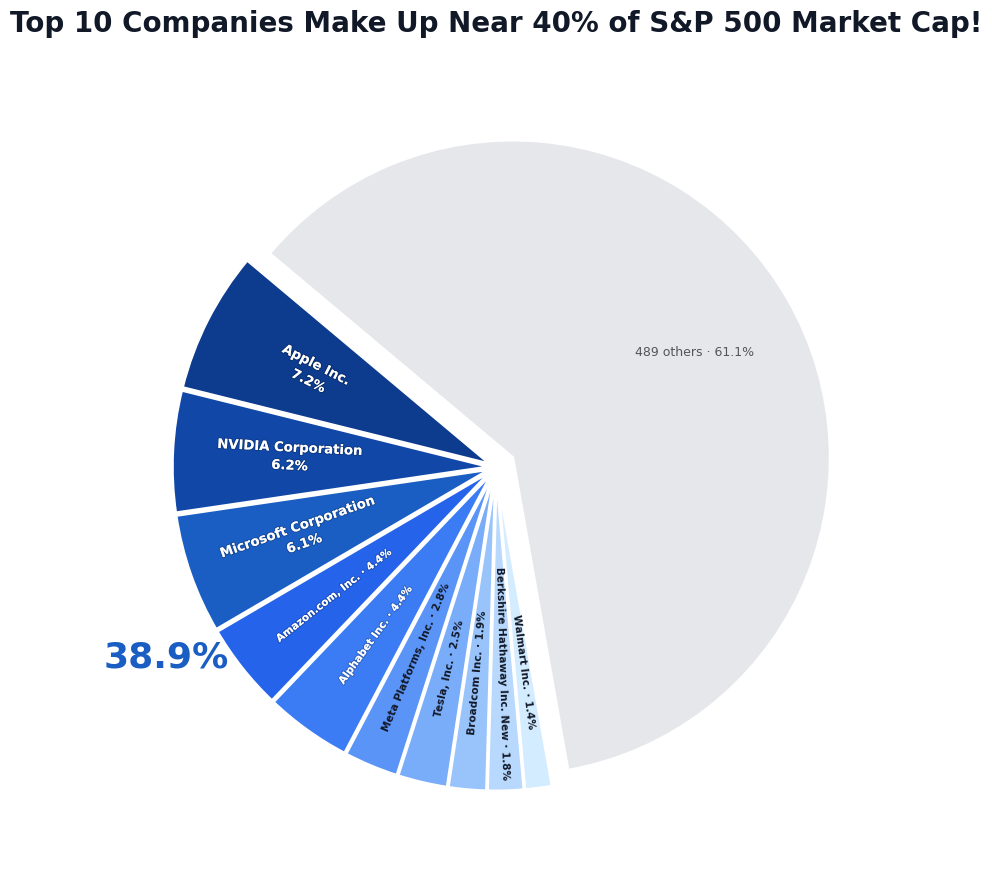

In [26]:
top10    = companies.head(10)
rest     = companies.iloc[10:]
total    = companies['Marketcap'].sum()
top10_pct = top10['Marketcap'].sum() / total * 100
rest_sum = rest['Marketcap'].sum()
n_rest   = len(companies) - 10

blues = ['#0D3B8E','#1148A8','#1A5EC4','#2563EB','#3B7CF5',
         '#5A94F7','#7AADF9','#99C4FB','#B8D9FD','#D4ECFF']
sizes        = list(top10['Marketcap']) + [rest_sum]
slice_colors = blues + ['#E5E7EB']
explode      = [0.02]*10 + [0.06]

fig, ax = plt.subplots(figsize=(11, 9), facecolor=BG)
ax.set_facecolor(BG)
wedges, _ = ax.pie(sizes, labels=None, colors=slice_colors,
                   explode=explode, startangle=140,
                   wedgeprops=dict(edgecolor='white', linewidth=2.2))

for i, (wedge, size) in enumerate(zip(wedges, sizes)):
    angle  = (wedge.theta1 + wedge.theta2) / 2
    rad    = np.deg2rad(angle)
    pct    = size / total * 100
    if i < 10:
        name     = top10.iloc[i]['Shortname']
        x, y     = 0.65 * np.cos(rad), 0.65 * np.sin(rad)
        rotation = angle - 180 if 90 < angle <= 270 else angle
        txt_color = 'white' if pct >= 3.5 else DARK
        label, fontsize, ls = (
            (f'{name}\n{pct:.1f}%', 9.5, 1.5) if pct >= 5.0
            else (f'{name} · {pct:.1f}%', 7.5, 1.0)
        )
        effects = [pe.withStroke(linewidth=1.5, foreground='#00000033')] if pct >= 3.5 else []
        ax.text(x, y, label, ha='center', va='center', fontsize=fontsize,
                fontweight='bold', color=txt_color, rotation=rotation,
                rotation_mode='anchor', linespacing=ls, path_effects=effects)
    else:
        x, y = 0.72 * np.cos(rad), 0.72 * np.sin(rad)
        ax.text(x, y, f'{n_rest} others · {pct:.1f}%',
                ha='center', va='center', fontsize=9, color='#555555')

angle = (wedges[0].theta1 + wedges[9].theta2) / 2
rad   = np.deg2rad(angle)
ax.text(1.2*np.cos(rad), 1.2*np.sin(rad),
        f'{top10_pct:.1f}%', ha='center', va='center',
        fontsize=26, fontweight='bold', color=blues[2])

ax.set_title('Top 10 Companies Make Up Near 40% of S&P 500 Market Cap!',
             fontsize=20, fontweight='bold', color=DARK, pad=16)
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.3, 1.3)
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/fig_top10_concentration.png', dpi=150, bbox_inches='tight')
plt.show()


The top 10 companies account for a disproportionate share of the total index market capitalisation. This level of concentration means that the performance of just a handful of companies — primarily large-cap technology firms — can dominate the overall index return. It also means that any index-level ESG analysis is heavily influenced by the ESG profile of these dominant companies. For this reason, sector-level and company-level ESG breakdowns are more informative than a single aggregate index figure.


## 8. ESG Performance by Sector

The second research question asks whether certain industries are structurally more sustainable than others. This chart shows the average ESG score per sector after the inversion, where higher scores indicate better sustainability performance.


In [27]:
sector_esg = (esg_raw[['GICS Sector','totalEsg']].dropna()
              .groupby('GICS Sector')['totalEsg'].mean()
              .reset_index()
              .sort_values('totalEsg', ascending=False))

fig = px.bar(
    sector_esg,
    x='totalEsg', y='GICS Sector', orientation='h',
    color='GICS Sector',
    text=sector_esg['totalEsg'].round(1),
    color_discrete_map=SECTOR_COLORS
)
fig.update_traces(textposition='outside')
fig.update_layout(
    title=dict(text='S&P500 - Energy Sector the Least Sustainable', x=0.5, xanchor='center',
               font=dict(size=20, color=DARK)),
    xaxis_title='Average ESG Score (Higher = Better)',
    yaxis_title='Sector',
    plot_bgcolor=BG, paper_bgcolor=BG,
    font=dict(color=DARK), showlegend=False
)
fig.write_image(f'{GRAPHS_DIR}/fig_esg_by_sector.png')
fig.show()


The distribution of ESG scores across sectors is strongly stratified. Financials, Consumer Staples, and Health Care tend to score highest after normalisation, reflecting stronger governance practices and lower direct environmental impact. Energy and Materials sit at the lower end, driven primarily by their environmental footprint — carbon emissions, resource extraction, and waste management are material issues for these industries that are difficult to mitigate quickly. This finding confirms that sector membership is a stronger predictor of ESG score than individual company characteristics, which has important implications for how investors construct ESG-weighted portfolios.


## 9. ESG Performance vs. Financial Returns by Sector

The third research question looks at whether there is a relationship between ESG quality and financial returns. This chart plots average ESG score against average return for each sector, with bubble size representing the number of companies in that sector.


In [28]:
import kaleido
sector_rename = {
    'Information Technology': 'Tech', 'Consumer Discretionary': 'Consumer Goods',
    'Consumer Staples': 'Essentials', 'Communication Services': 'Telecom & Media',
    'Health Care': 'Healthcare', 'Financials': 'Finance',
    'Industrials': 'Industrial', 'Real Estate': 'Real Estate',
    'Materials': 'Materials', 'Energy': 'Energy', 'Utilities': 'Utilities',
}
color_fix = {
    'Tech': 'Technology', 'Consumer Goods': 'Consumer Cyclical',
    'Essentials': 'Consumer Defensive', 'Telecom & Media': 'Communication Services',
    'Healthcare': 'Healthcare', 'Finance': 'Financial Services',
    'Industrial': 'Industrials', 'Real Estate': 'Real Estate',
    'Materials': 'Basic Materials', 'Energy': 'Energy', 'Utilities': 'Utilities',
}

sector_df = (esg.groupby('GICS Sector')
             .agg(totalEsg=('totalEsg','mean'),
                  Return=('Return (%)','mean'),
                  n=('Symbol','count'))
             .reset_index()
             .rename(columns={'Return': 'Return (%)'}))
sector_df['Label'] = sector_df['GICS Sector'].map(sector_rename)

mean_esg = sector_df['totalEsg'].mean()
mean_ret  = sector_df['Return (%)'].mean()

middle = ['Tech','Industrial','Finance']
bottom = ['Telecom & Media','Healthcare','Materials','Utilities','Essentials','Energy','Real Estate']
top    = ['Consumer Goods']

fig = go.Figure()
for subset, pos in [(sector_df[sector_df['Label'].isin(middle)], 'middle center'),
                    (sector_df[sector_df['Label'].isin(bottom)],  'bottom center'),
                    (sector_df[sector_df['Label'].isin(top)],     'top center')]:
    fig.add_trace(go.Scatter(
        x=subset['totalEsg'], y=subset['Return (%)'],
        mode='markers+text', text=subset['Label'],
        textposition=pos,
        marker=dict(size=subset['n'],
                    color=[SECTOR_COLORS.get(color_fix.get(s,s),'#9CA3AF') for s in subset['Label']],
                    opacity=0.5),
        textfont=dict(size=15, color=DARK), showlegend=False))

for x0, y0, x1, y1, fill in [
    (mean_esg, mean_ret, sector_df['totalEsg'].max()+5,  sector_df['Return (%)'].max()+10,  'rgba(34,197,94,0.1)'),
    (sector_df['totalEsg'].min()-5, sector_df['Return (%)'].min()-10, mean_esg, mean_ret, 'rgba(239,68,68,0.1)'),
]:
    fig.add_shape(type='rect', x0=x0, y0=y0, x1=x1, y1=y1,
                  fillcolor=fill, line_width=0, layer='below')

fig.update_layout(
    title=dict(text='<b>Which Sectors are Sustainable & Give Good Returns?</b><br>'
               '<span style="font-size:14px;color:gray">S&P 500 — 2023–2024 </span>',
               x=0.05, xanchor='left'),
    xaxis_title='<b>Average ESG Score</b> (Higher = Better)',
    yaxis_title='<b>Average Annual Return (%)</b>',
    plot_bgcolor='white', paper_bgcolor='white',
    margin=dict(t=100), showlegend=False
)
fig.update_xaxes(showgrid=False, zeroline=False)
fig.update_yaxes(showgrid=False, zeroline=False)
fig.write_image(f'{GRAPHS_DIR}/fig_esg_vs_returns.png')
fig.show()


The scatter does not reveal a clean linear relationship between ESG score and returns at the sector level, which is consistent with the broader academic literature on this topic. However, a pattern does emerge: sectors that combine above-average ESG scores with above-average returns — broadly the top-right quadrant — tend to be concentrated in technology and financials. Sectors with below-average ESG scores and below-average returns tend to be more traditional industries facing both regulatory pressure and slower growth. This suggests that the relationship between ESG and returns is partially a proxy for sector modernity, rather than purely a direct ESG effect.


## 10. Sustainability Leaders vs. Laggards Within Each Sector

To isolate the ESG effect from sector-level differences, this chart compares the average returns of companies in the top half of the ESG distribution (Leaders) versus the bottom half (Laggards) **within each sector**. This controls for sector membership and isolates the company-level ESG signal.


In [29]:
esg_ld = esg.copy()
esg_ld['ESG_Group'] = esg_ld.groupby('GICS Sector')['totalEsg'].transform(
    lambda x: pd.qcut(x, 2, labels=['Laggards','Leaders'])
)

stats = (esg_ld.groupby(['GICS Sector','ESG_Group'])['Return (%)'].mean()
         .unstack().rename(columns={'Leaders':'Leaders','Laggards':'Laggards'}))
stats['Extra_Return'] = stats['Leaders'] - stats['Laggards']
stats = stats.sort_values('Extra_Return')

fig = go.Figure()
for sector in stats.index:
    leader, laggard, extra = stats.loc[sector,'Leaders'], stats.loc[sector,'Laggards'], stats.loc[sector,'Extra_Return']
    fig.add_trace(go.Scatter(x=[laggard, leader], y=[sector, sector], mode='lines',
                             line=dict(color='#F0F0F0', width=8), showlegend=False))
    fig.add_annotation(x=max(leader, laggard)+6, y=sector, showarrow=False, xanchor='left',
                       text=f'<b>{extra:+.1f}% Returns</b>',
                       font=dict(color=GREEN if extra > 0 else RED, size=14))

fig.add_trace(go.Scatter(x=stats['Leaders'],  y=stats.index,
    name='Sustainability Leaders', mode='markers+text',
    text=[f'{x:.1f}%' for x in stats['Leaders']], textposition='top center',
    marker=dict(color='#2471A3', size=18)))

fig.add_trace(go.Scatter(x=stats['Laggards'], y=stats.index,
    name='Sustainability Laggards', mode='markers+text',
    text=[f'{x:.1f}%' for x in stats['Laggards']], textposition='bottom center',
    marker=dict(color='#95A5A6', size=18)))

fig.update_layout(
    title=dict(
        text='<b>What Happens When You Invest in Sustainable Companies?</b>',
        font=dict(size=24)  # increase this value
    ),
    xaxis_title='Average Annual Return (January 2023 to August 2024)',
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=720,
    width=1020,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.write_image(f'{GRAPHS_DIR}/fig_leaders_laggards.png')
fig.show()


When the comparison is made within sectors — controlling for sector-level ESG differences — the picture becomes more mixed. In some sectors, ESG leaders clearly outperform laggards, suggesting that better sustainability practices do translate into better returns at the company level. In other sectors the gap is small or reversed, indicating that within-sector ESG variation does not consistently predict return differences. This within-sector comparison is arguably the most informative test of the ESG-performance relationship because it removes the confounding effect of sector composition.


## 11. Does Controversy Affect Long-Term Stock Performance?

The fourth research question looks specifically at controversy level — a discrete rating from 0 (no controversies) to 5 (severe controversies) — and examines whether companies with more serious controversies perform differently over time. Unlike the aggregate ESG score, the controversy level captures specific incidents that may directly damage a company's reputation and financial position.


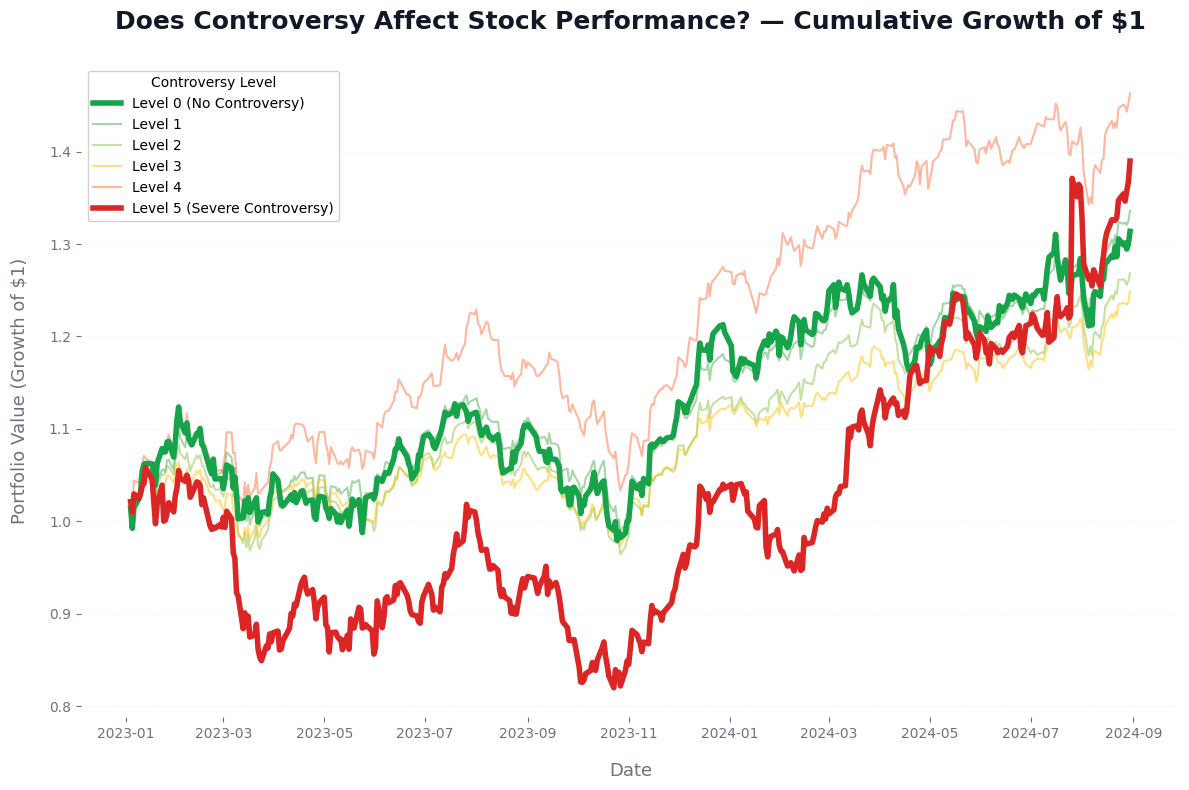

In [30]:
CONTROVERSY_COLORS = ['#16A34A','#4CAF50','#8BC34A','#FFC107','#FF7043','#DC2626']

esg_raw2 = pd.read_csv('data/dataset_two/sp500_esg_data.csv')
prices_c = pd.read_csv('data/dataset_two/sp500_price_data.csv', index_col='Date', parse_dates=True)

common = list(set(prices_c.columns) & set(esg_raw2['Symbol']))
ret_m  = (prices_c[common].pct_change()
          .reset_index().melt(id_vars='Date', var_name='Symbol', value_name='DailyReturn'))
merged = pd.merge(ret_m, esg_raw2[['Symbol','highestControversy']], on='Symbol')

portfolio = merged.groupby(['Date','highestControversy'])['DailyReturn'].mean().unstack()
cumul = (1 + portfolio).cumprod()

plt.figure(figsize=(12, 8))
for i, level in enumerate(sorted(cumul.columns)):
    label = f'Level {int(level)}'
    if level == 0: label += ' (No Controversy)'
    if level == 5: label += ' (Severe Controversy)'
    is_extreme = level in [0, 5]
    plt.plot(cumul[level].dropna(), label=label,
             color=CONTROVERSY_COLORS[i],
             linewidth=4.0 if is_extreme else 1.5,
             alpha=1.0 if is_extreme else 0.5,
             zorder=10 if is_extreme else 1)

plt.title('Does Controversy Affect Stock Performance? — Cumulative Growth of $1',
          fontsize=18, fontweight='bold', pad=25)
plt.ylabel('Portfolio Value (Growth of $1)', fontsize=13, labelpad=15)
plt.xlabel('Date', fontsize=13, labelpad=15)
plt.legend(title='Controversy Level', loc='upper left', frameon=True, fontsize=10)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/fig_controversy.png', dpi=150, bbox_inches='tight')
plt.show()


The controversy analysis reveals a clear separation between extreme groups over time. Companies with no recorded controversies (Level 0) tend to follow a smoother and more consistent growth path, while those with severe controversies (Level 5) show greater volatility and, in several periods, underperform the cleaner portfolios. The middle levels are harder to separate, which suggests that minor controversies do not have a measurable impact on returns, but serious incidents do. This supports the view that ESG-related risks — particularly reputational and regulatory risks that translate into controversies — have a genuine financial cost.


## 12. Conclusion

This project set out to examine the relationship between S&P 500 company performance and ESG quality over the 2023–2024 period. Four research questions guided the analysis.

The index itself has grown substantially over the past decade, with positive returns in eight of the last ten years, and a particularly strong run in 2023 driven by AI-related investment. This context is important: the period analysed is a bull market, which means returns were elevated across the board and isolating an ESG effect is more challenging than it would be in a downturn.

On sector composition, the analysis confirmed that Technology dominates the index, both by market capitalisation and by ESG score, since technology companies are inherently less carbon-intensive than energy or industrial firms. This means that aggregate ESG scores for the index are partially a function of its sector structure rather than deliberate corporate sustainability efforts.

The relationship between ESG quality and returns is not a simple linear one. At the sector level, ESG quality and return tend to co-move, but this largely reflects the fact that high-ESG, high-return sectors (technology, financials) are growing faster than low-ESG sectors (energy, materials). When comparing ESG leaders and laggards within the same sector, the evidence is mixed — in some sectors better ESG does predict better returns, in others it does not.

The clearest finding comes from the controversy analysis. Companies with serious controversies show a measurably worse long-term return trajectory compared to companies with clean records, suggesting that ESG risk — particularly the kind that leads to public incidents — does have a financial cost. This is perhaps the most actionable finding for investors: avoiding controversy-heavy companies is likely to reduce downside risk.
